# ECG Cardiovascular Disease Classification — DAT255 Project
**Authors:** Edvard Vindenes Steenslid & Morten Kvamme

**Objective:** Multi-label classification of cardiovascular conditions from the PTB-XL ECG dataset using 1D-CNN and LSTM architectures, with Grad-CAM interpretability.

**Metrics:** Accuracy, Recall, F1-Score (macro & per-class)

---

## Table of Contents
1. [Setup & Installations]
2. [Data Loading & Exploration]
3. [Preprocessing & Feature Engineering]
4. [Model 1 — 1D Convolutional Neural Network]
5. [Model 2 — LSTM Recurrent Network]
6. [Training with MLflow Tracking]
7. [Evaluation & Comparison]
8. [Grad-CAM Interpretability]
9. [Export for HuggingFace & Gradio Deployment]

## 1. Setup & Installations <a id='setup'></a>

In [18]:
# Install required packages (run once)
# NOTE: Keras 3 is the standalone version — we import 'keras' directly, NOT 'tensorflow.keras'
!pip install -q keras tensorflow wfdb pandas numpy matplotlib seaborn scikit-learn mlflow gradio huggingface_hub

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [19]:
import os
# Remove any leftover SQLite tracking URI from the environment
os.environ.pop("MLFLOW_TRACKING_URI", None)
import ast
import zipfile
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
import seaborn as sns

# ── Keras 3 (standalone) ──────────────────────────────────────────────
# Keras 3 auto-detects the backend (TensorFlow, JAX, or PyTorch).
# We set TensorFlow explicitly for Grad-CAM compatibility later.
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, callbacks, optimizers

# Scikit-learn metrics
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    multilabel_confusion_matrix,
    accuracy_score,
)
from sklearn.preprocessing import MultiLabelBinarizer

print(f"Keras version : {keras.__version__}")
print(f"Keras backend : {keras.backend.backend()}")
print(f"NumPy version : {np.__version__}")

Keras version : 3.13.2
Keras backend : tensorflow
NumPy version : 2.4.3


In [20]:
# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

## 2. Data Loading & Exploration <a id='data'></a>

The **PTB-XL** dataset contains 21,799 twelve-lead ECG recordings of 10 seconds each, sampled at 100 Hz (low-res) and 500 Hz (high-res). Each record is annotated with up to five **diagnostic superclasses**:

| Superclass | Description |
|------------|-------------------------------|
| **NORM**   | Normal ECG |
| **MI**     | Myocardial Infarction |
| **STTC**   | ST/T Change |
| **CD**     | Conduction Disturbance |
| **HYP**    | Hypertrophy |

The dataset ships with a **10-fold stratified split** (`strat_fold` column). The standard convention is:
- Folds 1–8 → Training
- Fold 9 → Validation
- Fold 10 → Test

In [21]:
# ── 2.1 Unzip the dataset ──────────────────────────────────────────
# Update this path to wherever your zip file is located
ZIP_PATH = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip"
DATA_DIR = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

if not os.path.isdir(DATA_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")
    print("Done.")
else:
    print(f"Dataset directory already exists: {DATA_DIR}")

# List top-level contents
os.listdir(DATA_DIR)

Dataset directory already exists: ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3


['example_physionet.py',
 'LICENSE.txt',
 'ptbxl_database.csv',
 'ptbxl_v102_changelog.txt',
 'ptbxl_v103_changelog.txt',
 'RECORDS',
 'records100',
 'records500',
 'scp_statements.csv',
 'SHA256SUMS.txt']

In [22]:
# ── 2.2  Load metadata ──────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, "ptbxl_database.csv"), index_col="ecg_id")

# Parse the scp_codes column (stored as string repr of dict)
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

print(f"Total records: {len(df)}")
df.head()

Total records: 21799


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [23]:
# ── 2.3 Clean metadata & map SCP codes to superclasses ─────────────
# Load the SCP statement lookup table
scp_df = pd.read_csv(os.path.join(DATA_DIR, "scp_statements.csv"), index_col=0)
scp_df = scp_df[scp_df["diagnostic"] == 1]  # keep only diagnostic codes

# Build a dict: scp_code -> diagnostic_class (superclass)
code_to_superclass = scp_df["diagnostic_class"].to_dict()

SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
NUM_CLASSES = len(SUPERCLASSES)

# ── Drop columns that are almost entirely NaN (identified in EDA) ──
# electrodes_problems (99.9%), infarction_stadium2 (99.5%),
# pacemaker (98.7%), burst_noise (97.2%), baseline_drift (92.7%),
# extra_beats (91.1%), static_noise (85.0%)
HIGH_NAN_COLS = [
    "electrodes_problems", "infarction_stadium2", "pacemaker",
    "burst_noise", "baseline_drift", "extra_beats", "static_noise",
]
df.drop(columns=[c for c in HIGH_NAN_COLS if c in df.columns], inplace=True)
print(f"Dropped {len(HIGH_NAN_COLS)} high-NaN columns")

# ── Remove age outliers (EDA found age=300) ────────────────────────
MAX_AGE = 120
n_age_outliers = (df["age"] > MAX_AGE).sum()
df = df[df["age"] <= MAX_AGE].copy()
print(f"Removed {n_age_outliers} records with age > {MAX_AGE}")

def extract_superclasses(scp_dict):
    """Given a dict of {scp_code: likelihood}, return the set of superclasses.
    
    Only codes with likelihood >= 50 are considered, matching the
    convention used in the PTB-XL benchmarking paper (Wagner et al., 2020).
    """
    classes = set()
    for code, likelihood in scp_dict.items():
        if code in code_to_superclass and likelihood >= 50:
            sc = code_to_superclass[code]
            if sc in SUPERCLASSES:
                classes.add(sc)
    return classes

df["superclasses"] = df["scp_codes"].apply(extract_superclasses)

# Drop records with no diagnostic superclass
n_before = len(df)
df = df[df["superclasses"].apply(len) > 0].copy()
print(f"\nRecords before filtering: {n_before}")
print(f"Records after filtering : {len(df)}")
print(f"Dropped (no diagnosis)  : {n_before - len(df)}")
print(f"Columns remaining       : {len(df.columns)}")

Dropped 7 high-NaN columns
Removed 293 records with age > 120

Records before filtering: 21506
Records after filtering : 20095
Dropped (no diagnosis)  : 1411
Columns remaining       : 21


In [24]:
# ── 2.4  Binarize labels (multi-label) ──────────────────────────────
mlb = MultiLabelBinarizer(classes=SUPERCLASSES)
labels = mlb.fit_transform(df["superclasses"])
df[SUPERCLASSES] = labels

print("Label distribution:")
for i, sc in enumerate(SUPERCLASSES):
    print(f"  {sc:5s}: {labels[:, i].sum():6d}  ({labels[:, i].mean()*100:.1f}%)")

print(f"\nMulti-label samples: {(labels.sum(axis=1) > 1).sum()} "
      f"({(labels.sum(axis=1) > 1).mean()*100:.1f}%)")

Label distribution:
  NORM :   9407  (46.8%)
  MI   :   4034  (20.1%)
  STTC :   4952  (24.6%)
  CD   :   4749  (23.6%)
  HYP  :   2208  (11.0%)

Multi-label samples: 4265 (21.2%)


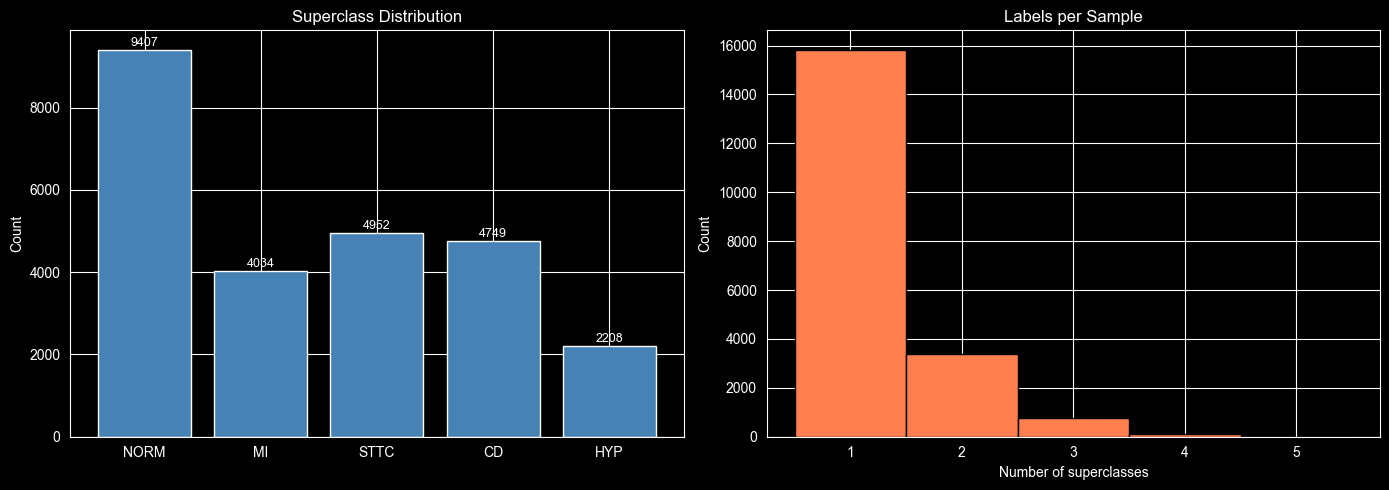

In [25]:
# ── 2.5  Visualise label distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of class counts
counts = [labels[:, i].sum() for i in range(NUM_CLASSES)]
axes[0].bar(SUPERCLASSES, counts, color="steelblue")
axes[0].set_title("Superclass Distribution")
axes[0].set_ylabel("Count")
for i, c in enumerate(counts):
    axes[0].text(i, c + 100, str(c), ha="center", fontsize=9)

# Number of labels per sample
n_labels = labels.sum(axis=1)
axes[1].hist(n_labels, bins=range(1, 7), align="left", color="coral", edgecolor="k")
axes[1].set_title("Labels per Sample")
axes[1].set_xlabel("Number of superclasses")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# ── 2.6 Load ECG waveforms ─────────────────────────────────────────
# We use the 100 Hz version (1000 timesteps x 12 leads) for speed.
# Switch to filename_hr for the 500 Hz version (5000 x 12) if desired.

SAMPLING_RATE = 100  # Hz

def load_raw_signals(df, data_dir, sampling_rate=100):
    """Load all ECG signals into a numpy array."""
    col = "filename_lr" if sampling_rate == 100 else "filename_hr"
    signals = []
    for idx, row in df.iterrows():
        fpath = os.path.join(data_dir, row[col])
        record = wfdb.rdrecord(fpath)
        signals.append(record.p_signal)  # shape: (timesteps, 12)
    return np.array(signals, dtype=np.float32)

print("Loading ECG signals (this takes a few minutes)...")
X_all = load_raw_signals(df, DATA_DIR, SAMPLING_RATE)
y_all = labels.astype(np.float32)

print(f"Signals shape : {X_all.shape}")   # (N, 1000, 12)
print(f"Labels shape  : {y_all.shape}")    # (N, 5)

Loading ECG signals (this takes a few minutes)...
Signals shape : (20095, 1000, 12)
Labels shape  : (20095, 5)


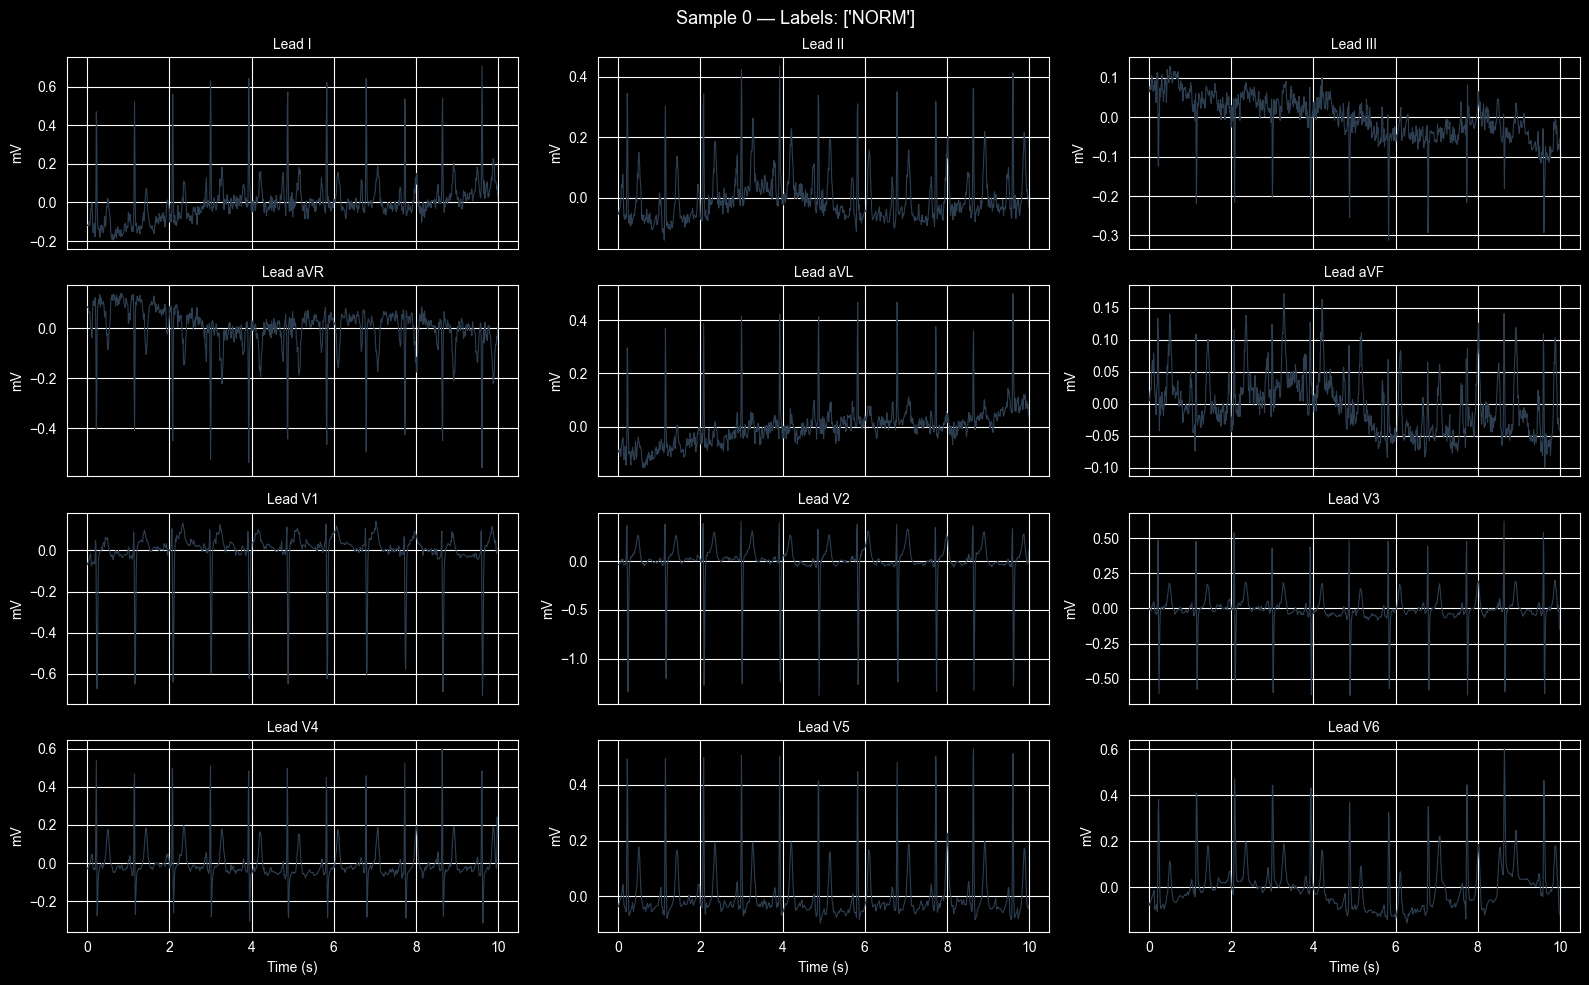

In [27]:
# ── 2.7  Visualise example ECG traces ───────────────────────────────
LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]

fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex=True)
sample_idx = 0
time = np.arange(X_all.shape[1]) / SAMPLING_RATE  # seconds

for i, ax in enumerate(axes.flat):
    ax.plot(time, X_all[sample_idx, :, i], linewidth=0.8, color="#2c3e50")
    ax.set_title(f"Lead {LEAD_NAMES[i]}", fontsize=10)
    ax.set_ylabel("mV")
    if i >= 9:
        ax.set_xlabel("Time (s)")

sc_labels = [SUPERCLASSES[j] for j in range(NUM_CLASSES) if y_all[sample_idx, j] == 1]
fig.suptitle(f"Sample {sample_idx} — Labels: {sc_labels}", fontsize=13)
plt.tight_layout()
plt.savefig("ecg_example.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Preprocessing & Feature Engineering <a id='preprocess'></a>

In [28]:
# ── 3.1  Train / Validation / Test split (PTB-XL convention) ───────
folds = df["strat_fold"].values

train_mask = folds <= 8
val_mask   = folds == 9
test_mask  = folds == 10

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f"Train : {X_train.shape[0]:6d} samples")
print(f"Val   : {X_val.shape[0]:6d} samples")
print(f"Test  : {X_test.shape[0]:6d} samples")

Train :  16083 samples
Val   :   1994 samples
Test  :   2018 samples


In [29]:
# ── 3.2  Z-score normalisation (per-channel, fitted on train) ──────
# This is standard practice for ECG — removes baseline wander effects
# and puts all leads on a comparable scale.

train_mean = X_train.mean(axis=(0, 1), keepdims=True)  # (1, 1, 12)
train_std  = X_train.std(axis=(0, 1), keepdims=True)   # (1, 1, 12)
train_std[train_std == 0] = 1.0  # avoid division by zero

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

# ── Clip extreme values (EDA found artefacts up to ±13 mV on V2/V4/V5) ──
# After Z-normalisation, clip to ±10σ to prevent outlier signals from
# distorting the loss. This preserves >99.99% of data unchanged.
CLIP_STD = 10.0
X_train = np.clip(X_train, -CLIP_STD, CLIP_STD)
X_val   = np.clip(X_val,   -CLIP_STD, CLIP_STD)
X_test  = np.clip(X_test,  -CLIP_STD, CLIP_STD)

# Save normalisation params for deployment later
np.savez("normalisation_params.npz", mean=train_mean, std=train_std)
print("Normalisation + clipping applied. Stats saved to normalisation_params.npz")
print(f"Train range: [{X_train.min():.2f}, {X_train.max():.2f}]")

Normalisation + clipping applied. Stats saved to normalisation_params.npz
Train range: [-10.00, 10.00]


In [30]:
# ── 3.3  Compute class weights (address imbalance) ─────────────────
# For multi-label BCE, we weight each class inversely proportional
# to its frequency, so rare conditions get more attention.

pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
class_weights_array = neg_counts / (pos_counts + 1e-7)

print("Class weights (neg/pos ratio):")
for i, sc in enumerate(SUPERCLASSES):
    print(f"  {sc:5s}: {class_weights_array[i]:.2f}")

Class weights (neg/pos ratio):
  NORM : 1.14
  MI   : 3.97
  STTC : 3.05
  CD   : 3.23
  HYP  : 8.02


## 4. Model 1 — 1D Convolutional Neural Network <a id='cnn'></a>

**Architecture rationale:** 1D-CNNs are highly effective for ECG classification because they can learn local morphological features (QRS complex width, ST-segment elevation, T-wave inversions) through convolutional filters that slide along the temporal axis. Multiple layers of convolutions capture increasingly abstract patterns — from individual wave shapes to complex arrhythmia signatures.

Our architecture uses:
- **4 convolutional blocks** with increasing filter counts (32 → 64 → 128 → 256)
- **Batch normalisation** after each conv layer for training stability
- **MaxPooling** to reduce temporal resolution and build translation invariance
- **Dropout** for regularisation
- **Global Average Pooling** before the classifier head (more robust than Flatten, also required for Grad-CAM)

In [31]:
# ── 4.1  Build the 1D-CNN ───────────────────────────────────────────

def build_cnn(input_shape, num_classes, dropout_rate=0.3):
    """
    1D-CNN for multi-label ECG classification.

    Architecture:
        Input (1000, 12)
          -> [Conv1D -> BN -> ReLU -> MaxPool -> Dropout] x 4 blocks
          -> GlobalAveragePooling1D
          -> Dense(128) -> Dropout -> Dense(num_classes, sigmoid)
    """
    inputs = keras.Input(shape=input_shape, name="ecg_input")

    # ── Block 1 ──
    x = layers.Conv1D(32, kernel_size=7, padding="same", name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool1")(x)
    x = layers.Dropout(dropout_rate)(x)

    # ── Block 2 ──
    x = layers.Conv1D(64, kernel_size=5, padding="same", name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool2")(x)
    x = layers.Dropout(dropout_rate)(x)

    # ── Block 3 ──
    x = layers.Conv1D(128, kernel_size=5, padding="same", name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool3")(x)
    x = layers.Dropout(dropout_rate)(x)

    # ── Block 4 (last conv — target for Grad-CAM) ──
    x = layers.Conv1D(256, kernel_size=3, padding="same", name="conv4_gradcam")(x)
    x = layers.BatchNormalization(name="bn4")(x)
    x = layers.Activation("relu", name="conv4_relu")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool4")(x)
    x = layers.Dropout(dropout_rate)(x)

    # ── Classifier head ──
    x = layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="sigmoid", name="predictions")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="ECG_1D_CNN")
    return model


INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])  # (1000, 12)

cnn_model = build_cnn(INPUT_SHAPE, NUM_CLASSES)
cnn_model.summary()

Model: "ECG_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 1000, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1000, 32)       │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1000, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 500, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 500, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 250, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 250, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_gradcam (Conv1D)          │ (None, 125, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 125, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_relu (Activation)         │ (None, 125, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling1D)            │ (None, 62, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 62, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           64

 Total params: 188,133 (734.89 KB)

 Trainable params: 187,173 (731.14 KB)

 Non-trainable params: 960 (3.75 KB)

## 5. Model 2 — LSTM Recurrent Network <a id='lstm'></a>

**Architecture rationale:** LSTMs capture long-range temporal dependencies in sequential data. For ECG signals, this means the model can learn relationships between events separated in time — for example, linking the morphology of the P-wave to the subsequent QRS complex, or detecting sustained ST-segment changes across multiple heartbeats.

Our architecture uses:
- **A 1D Conv front-end** (feature extraction + downsampling) to reduce sequence length before the LSTM — this makes training significantly faster and helps the LSTM focus on higher-level patterns
- **Bidirectional LSTM** so the model reads the ECG both forward and backward in time
- **Two stacked LSTM layers** for hierarchical temporal representation
- **Dropout** on both input and recurrent connections

In [32]:
# ── 5.1  Build the LSTM ─────────────────────────────────────────────

def build_lstm(input_shape, num_classes, dropout_rate=0.3):
    """
    Bidirectional LSTM with a convolutional front-end for ECG classification.

    Architecture:
        Input (1000, 12)
          -> Conv1D(64, k=7) -> BN -> ReLU -> MaxPool(4)
          -> Bidirectional(LSTM(128, return_sequences)) -> Dropout
          -> Bidirectional(LSTM(64)) -> Dropout
          -> Dense(128) -> Dropout -> Dense(num_classes, sigmoid)
    """
    inputs = keras.Input(shape=input_shape, name="ecg_input")

    # ── Conv front-end: extract local features + downsample ──
    x = layers.Conv1D(64, kernel_size=7, padding="same", name="lstm_conv1")(inputs)
    x = layers.BatchNormalization(name="lstm_bn1")(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=4, name="lstm_pool1")(x)  # 1000 -> 250
    x = layers.Dropout(dropout_rate)(x)

    # ── Recurrent layers ──
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=dropout_rate,
                    recurrent_dropout=0.1),
        name="bi_lstm1"
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False, dropout=dropout_rate,
                    recurrent_dropout=0.1),
        name="bi_lstm2"
    )(x)

    # ── Classifier head ──
    x = layers.Dense(128, activation="relu", name="lstm_fc1")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="sigmoid", name="predictions")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="ECG_BiLSTM")
    return model


lstm_model = build_lstm(INPUT_SHAPE, NUM_CLASSES)
lstm_model.summary()

Model: "ECG_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 1000, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_conv1 (Conv1D)             │ (None, 1000, 64)       │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_bn1 (BatchNormalization)   │ (None, 1000, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1000, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_pool1 (MaxPooling1D)       │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm1 (Bidirectional)        │ (None, 250, 256)       │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_fc1 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384,837 (1.47 MB)

 Trainable params: 384,709 (1.47 MB)

 Non-trainable params: 128 (512.00 B)

## 6. Training with MLflow Tracking <a id='training'></a>

We use [MLflow](https://mlflow.org/) to log training metrics, hyperparameters, and artifacts. This allows interactive comparison of experiments via the MLflow UI.

**Training details:**
- **Loss:** Binary cross-entropy (standard for multi-label classification with sigmoid outputs)
- **Optimiser:** Adam with initial LR of 1e-3
- **Callbacks:** ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, MLflow autologging

After training, launch the MLflow UI with:
```bash
mlflow ui
```

In [33]:
# ── 6.1  MLflow setup ───────────────────────────────────────────────
import mlflow
import mlflow.keras

# ── Force a local file-based tracking store (avoids the SQLite registry issue) ──
mlflow.set_tracking_uri("file:./mlruns")

# Set the experiment name (creates it if it doesn't exist)
EXPERIMENT_NAME = "ECG_Classification_DAT255"
mlflow.set_experiment(EXPERIMENT_NAME)

# Enable Keras autologging — this automatically captures:
# metrics per epoch, model architecture, optimizer config, and the trained model.
mlflow.keras.autolog()

print(f"MLflow experiment: {EXPERIMENT_NAME}")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print("After training, run 'mlflow ui' to launch the dashboard.")

C:\Users\edvar\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/13 11:55:48 INFO mlflow.tracking.fluent: Experiment with name 'ECG_Classification_DAT255' does not exist. Creating a new experiment.


MLflow experiment: ECG_Classification_DAT255
MLflow tracking URI: file:./mlruns
After training, run 'mlflow ui' to launch the dashboard.


In [34]:
# ── 6.2  Training utility function ──────────────────────────────────

def train_model(
    model,
    X_train, y_train,
    X_val, y_val,
    experiment_name,
    epochs=50,
    batch_size=64,
    learning_rate=1e-3,
):
    """
    Compile, train, and return a model with full MLflow tracking.
    """
    # ── Compile ──
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc", multi_label=True),
            keras.metrics.Recall(name="recall"),
            keras.metrics.Precision(name="precision"),
        ],
    )

    # ── Callbacks ──
    checkpoint_path = f"best_{experiment_name}.keras"

    cb_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=10,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    # ── MLflow run ──
    with mlflow.start_run(run_name=experiment_name):
        # Log hyperparameters
        mlflow.log_params({
            "model_name": model.name,
            "epochs": epochs,
            "batch_size": batch_size,
            "learning_rate": learning_rate,
            "dropout": 0.3,
            "optimizer": "Adam",
            "loss": "binary_crossentropy",
            "num_params": model.count_params(),
            "input_shape": str(INPUT_SHAPE),
            "sampling_rate": SAMPLING_RATE,
        })

        # Train (autolog captures per-epoch metrics automatically)
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=cb_list,
            verbose=1,
        )

        # Log the best model as an artifact
        mlflow.log_artifact(checkpoint_path)

        # Log final validation metrics explicitly
        best_epoch = np.argmax(history.history["val_auc"])
        mlflow.log_metrics({
            "best_val_auc": history.history["val_auc"][best_epoch],
            "best_val_loss": history.history["val_loss"][best_epoch],
            "best_val_accuracy": history.history["val_accuracy"][best_epoch],
            "best_epoch": best_epoch + 1,
        })

    # ── Load best weights ──
    model = keras.saving.load_model(checkpoint_path)
    print(f"\nLoaded best model from {checkpoint_path}")

    return model, history

In [ ]:
# ── 6.3  Train the 1D-CNN ──────────────────────────────────────────
print("=" * 60)
print("TRAINING: 1D-CNN")
print("=" * 60)

cnn_model, cnn_history = train_model(
    model=cnn_model,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    experiment_name="1D_CNN",
    epochs=50,
    batch_size=64,
    learning_rate=1e-3,
)

TRAINING: 1D-CNN


Epoch 1/50
251/252 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8036 - auc: 0.7714 - loss: 0.4302 - precision: 0.6612 - recall: 0.4522
Epoch 1: val_auc improved from None to 0.88786, saving model to best_1D_CNN.keras

Epoch 1: finished saving model to best_1D_CNN.keras
252/252 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.8376 - auc: 0.8452 - loss: 0.3708 - precision: 0.7342 - recall: 0.5591 - val_accuracy: 0.8253 - val_auc: 0.8879 - val_loss: 0.4785 - val_precision: 0.6853 - val_recall: 0.5663 - learning_rate: 0.0010
Epoch 2/50
251/252 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8708 - auc: 0.8929 - loss: 0.3123 - precision: 0.7885 - recall: 0.6673
Epoch 2: val_auc improved from 0.88786 to 0.89452, saving model to best_1D_CNN.keras

Epoch 2: finished saving model to best_1D_CNN.keras
252/252 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.8733 - auc: 0.8976 - loss: 0.3056 - precision: 0.7926 - recall: 0.6746 - val_accuracy: 0.8494 - val_auc: 0.8945 - val_loss: 0.4097 - val_

In [ ]:
# ── 6.4  Train the BiLSTM ──────────────────────────────────────────
print("=" * 60)
print("TRAINING: Bidirectional LSTM")
print("=" * 60)

lstm_model, lstm_history = train_model(
    model=lstm_model,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    experiment_name="BiLSTM",
    epochs=50,
    batch_size=64,
    learning_rate=1e-3,
)

In [ ]:
# ── 6.5  Plot training curves ──────────────────────────────────────

def plot_training_curves(histories, names, metrics=("loss", "accuracy", "auc")):
    """Plot training & validation curves for multiple models side by side."""
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, 5))
    colors = ["#2980b9", "#e74c3c"]

    for col, metric in enumerate(metrics):
        ax = axes[col]
        for i, (history, name) in enumerate(zip(histories, names)):
            ax.plot(history.history[metric], label=f"{name} train",
                    color=colors[i], linestyle="-")
            ax.plot(history.history[f"val_{metric}"], label=f"{name} val",
                    color=colors[i], linestyle="--")
        ax.set_title(metric.upper())
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_training_curves(
    [cnn_history, lstm_history],
    ["1D-CNN", "BiLSTM"],
)

## 7. Evaluation & Comparison <a id='evaluation'></a>

We evaluate on the **held-out test set** (fold 10) using:
- **Per-class Precision, Recall, F1-score**
- **Macro-averaged F1** (treats all classes equally — important given imbalance)
- **Subset accuracy** (exact match — strict)
- **Sample-based accuracy** (Jaccard-style per sample)
- **ROC-AUC** (macro, per-class)

In [ ]:
# ── 7.1  Evaluation utility ────────────────────────────────────────

def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    """Full evaluation with classification report, AUC, and confusion matrices."""
    # Predict probabilities
    y_prob = model.predict(X_test, batch_size=128)
    y_pred = (y_prob >= threshold).astype(np.float32)

    # ── Classification report ──
    print(f"\n{'='*60}")
    print(f"  Evaluation: {model_name}")
    print(f"{'='*60}")
    print(classification_report(
        y_test, y_pred,
        target_names=SUPERCLASSES,
        digits=4,
        zero_division=0,
    ))

    # ── Key metrics ──
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_micro = f1_score(y_test, y_pred, average="micro", zero_division=0)
    try:
        auc_macro = roc_auc_score(y_test, y_prob, average="macro")
    except ValueError:
        auc_macro = float("nan")

    # Subset accuracy (exact match for all 5 labels)
    subset_acc = accuracy_score(y_test, y_pred)

    # Sample-based Jaccard accuracy
    sample_acc = np.mean([
        np.sum(y_test[i] * y_pred[i]) /
        max(np.sum(y_test[i] + y_pred[i] - y_test[i] * y_pred[i]), 1)
        for i in range(len(y_test))
    ])

    print(f"  F1 (macro)       : {f1_macro:.4f}")
    print(f"  F1 (micro)       : {f1_micro:.4f}")
    print(f"  ROC-AUC (macro)  : {auc_macro:.4f}")
    print(f"  Subset accuracy  : {subset_acc:.4f}")
    print(f"  Sample accuracy  : {sample_acc:.4f}")

    return {
        "name": model_name,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "auc_macro": auc_macro,
        "subset_acc": subset_acc,
        "sample_acc": sample_acc,
    }

In [ ]:
# ── 7.2  Evaluate both models ─────────────────────────────────────
cnn_results  = evaluate_model(cnn_model, X_test, y_test, "1D-CNN")
lstm_results = evaluate_model(lstm_model, X_test, y_test, "BiLSTM")

In [ ]:
# ── 7.3  Side-by-side comparison table ─────────────────────────────
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("y_prob", "y_pred")}
    for r in [cnn_results, lstm_results]
]).set_index("name")

print("\n" + "="*60)
print("  MODEL COMPARISON")
print("="*60)
print(comparison.to_string(float_format="{:.4f}".format))

In [ ]:
# ── 7.4  Per-class confusion matrices ──────────────────────────────

def plot_multilabel_confusion(y_true, y_pred, class_names, title):
    """Plot per-class binary confusion matrices."""
    fig